### <p style="text-align: right;"> &#9989; Put your name here</p>

____
# Day 10 Pre-class Assignment: ZOMBIES!!
____
<img src="https://s-media-cache-ak0.pinimg.com/736x/68/d3/bc/68d3bccc93b1c64bd46c80e95bd400ee.jpg" width=300px>

### Goals for today's pre-class assignment:
* Continue to explore compartmental models using `odeint`
* Understand the dynamics of a disease outbreak models and the parameters that determine their behavior.

### Assignment instructions

**This assignment is due by 11:59 p.m. the day before class,** and should be uploaded into the "Pre-class assignments" submission folder for Day 11.  Submission instructions can be found at the end of the notebook.

---
In this notebook we model a zombie invasion, and use it to demonstrate how to use SciPy's `odeint`. The model used here is described in the paper by Munz et al.:

[WHEN ZOMBIES ATTACK!: MATHEMATICAL MODELING OF AN OUTBREAK OF ZOMBIE INFECTION](http://loe.org/images/content/091023/Zombie%20Publication.pdf)
<br>(DOWNLOAD A COPY OF THIS)

The original [code is here](http://scipy.github.io/old-wiki/pages/Cookbook/Zombie_Apocalypse_ODEINT), which has only been modified slightly. In this assignment you will be starting with the basic, working code and modifying it to model more interesting scenarios. So, first, read through and understand the basic structure of the solution; below, the basic code is the new stuff you need to think about before modifying the code.

The zombie model is a [**compartmental model**](http://www4.ncsu.edu/~msolufse/Compartmentmodels.pdf) that uses three compartments **S**, **Z**, and **R**:

<img src="https://i.imgur.com/9HTp47I.png" width=800>

The ODE version of this, using the notation in the code below, is:
$$\frac{dS}{dt} = P - BSZ - dS,$$
$$\frac{dZ}{dt} = BSZ + GR - ASZ,$$
$$\frac{dR}{dt} = dS + ASZ - GR.$$


**Note**: The code below doesn't use exactly same parameters that are stated in the paper and so you shouldn't be trying to compare the plots in the paper to the ones that you get. In fact, it turns out that the author of the paper was a bit sloppy with their code and wasn't consistent with the parameters used in their model. Additionally, they didn't use an accurate solver like `odeint` to evolve their system! If you take a look at their code at the end of the paper, you can even see that they made a simplifying assumption in their model that isn't well explained in the paper. This is a good example of how **_not_** to write a high-quality paper. Of course, exploring this model is still valuable and we'll make sure we do it correctly!

**Run the code below to make sure it works and produces three plots. Review the code and make sure you understand how it works.**

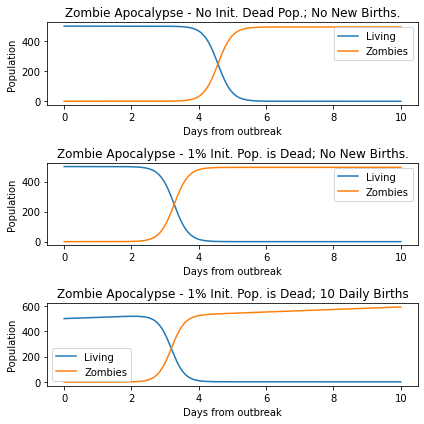

In [2]:
# Basic Zombie Model
#
# This code runs the basic zombie model for three different initial
# conditions for the same model. You will do something very similar, but 
# run the same initial conditions for four different models.

# Import the usual libraries; most important are the visualization
# and SciPy's odeint.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import odeint
from IPython.display import display, clear_output, set_matplotlib_formats

# The parameters of the model are collected and defined here.
P = 0       # birth rate
d = 0.0001  # natural death percent (per day)
B = 0.0095  # transmission percent  (per day)
G = 0.0001  # resurrect percent (per day)
A = 0.0001   # destroy percent  (per day)

# The model is expressed in terms of ODEs and this is where
# they are defined in a manner consistent with what odeint wants to see.
# solve the system dy/dt = f(y, t)
def f(y, t, P, d, B, G, A):
        Si = y[0]
        Zi = y[1]
        Ri = y[2]
        # the model equations (see Munz et al. 2009)
        f0 = P - B*Si*Zi - d*Si
        f1 = B*Si*Zi + G*Ri - A*Si*Zi
        f2 = d*Si + A*Si*Zi - G*Ri
        return [f0, f1, f2]

# initial conditions
S0 = 500.               # initial population
Z0 = 0                  # initial zombie population
R0 = 0                  # initial death population
y0 = [S0, Z0, R0]       # initial condition vector
t  = np.linspace(0, 10., 1000)   # time grid

# solve the DEs
soln = odeint(f, y0, t, args=(P, d, B, G, A))
S = soln[:, 0]
Z = soln[:, 1]
R = soln[:, 2]

plt.figure(figsize=(6,6))
# plot results
plt.subplot(311)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - No Init. Dead Pop.; No New Births.')
plt.legend(loc=0)


# change the initial conditions
# you could also use this to call a different/modified model for
# comparison by defining a different function "f" and giving
# appropriate initial conditions and parameters
R0 = 0.01*S0   # 1% of initial pop is dead
y0 = [S0, Z0, R0]

# solve the DEs
soln = odeint(f, y0, t, args=(P, d, B, G, A))
S = soln[:, 0]
Z = soln[:, 1]
R = soln[:, 2]

plt.subplot(312)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - 1% Init. Pop. is Dead; No New Births.')
plt.legend(loc=0)


# change the initial conditions to compare solutions
# you could also use this to call a different/modified model for
# comparison by defining a different function "f" and giving
# appropriate initial conditions and parameters
R0 = 0.01*S0   # 1% of initial pop is dead
P  = 10        # 10 new births daily
y0 = [S0, Z0, R0]

# solve the DEs
soln = odeint(f, y0, t, args=(P, d, B, G, A))
S = soln[:, 0]
Z = soln[:, 1]
R = soln[:, 2]

plt.subplot(313)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - 1% Init. Pop. is Dead; 10 Daily Births')
plt.legend(loc=0)

plt.tight_layout()

___
### Zombie Mitigation
___

If/when there is a zombie invasion, the Centers for Disease Control and Prevention will be in charge of mitigating the impending disaster. There are various tools in their toolbox for doing this, which have been developed for other diseases, but they are very busy dealing with things like Zika to have the resources to think about zombies right now. It would be great if you could help them by thinking  about what to do in advance. Luckily, some work has already been done on this. Munz et al. have explored two mitigation strategies:
* quarantine
* treatment

Unfortunately, they did not directly compare them. They claim that with treatment there is no reason for quarantine. Let's compare the two mitigation strategies to see what the differences are. First, we need to modify the code above to have a "latent" class, which they call **I**, and they call this the SIZR model. Skim the paper by Munz et al. (the one you downloaded earlier) and describe what a latent class is (see Section 3 in particular):


**Explain the latent class here:**
    

By the way, a comment on notation.... In the video lecture for this week, we used a different, hopefully-more-intuitive notation for the compartmental variables. Munz et al. seem to be using strange notation, but here is the logic:
* **S** is very often used for "susceptible" to refer to people who can get a disease (some people may have some immunity).
* **I** refers to "infected", which means they have the disease; in many cases this is called **L** so that **I** can be used to refer to those that are infectious (i.e. can spread the disease). In our simple zombie model, this is represented by Z.
* **R** refers to "recovered" or "removed". In the zombie model this is complicated by the fact that the "removed" can be resurrected! So, in some sense, it is a bad choice for this model (in our humble opinion!).

When we model infectious diseases, you will see more of this notation.

Next, **copy the code above and modify it to include the latent class**, as in the Munz paper on page 6. See Figure 4, page 7, for the compartmental model associated with this additional feature. Put the new version of the code here, using a different name for the function so that you can still use the original as a baseline case for comparison. We want to compare these, so be sure to keep things organized as separate functions.

For this model, **you need to implement a new parameter, $\rho$**. However, don't use the value that they mention in the paper. Instead, use $\rho = 0.5$, which will shorten the length of time that individuals stay in the latent class before they become zombies. For this section **run the model for 20 days** since the latent phase will stall the zombie take-over!

You should get something that looks like this:

<img src="https://i.imgur.com/i3FuLFC.png" width=500px>

Put your code and plots here:

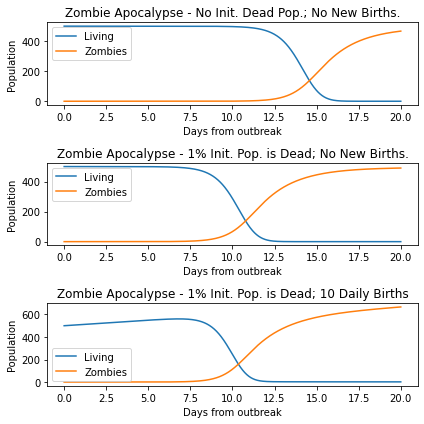

In [3]:
### ANSWER ###

# Basic Zombie Model
#
# This code runs the basic zombie model for three different initial
# conditions for the same model. You will do something very similar, but 
# run the same initial conditions for four different models.

# Import the usual libraries; most important are the visualization
# and SciPy's odeint.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.integrate import odeint
from IPython.display import display, clear_output, set_matplotlib_formats

# The parameters of the model are collected and defined here.
P = 0       # birth rate
d = 0.0001  # natural death percent (per day)
B = 0.0095  # transmission percent  (per day)
G = 0.0001  # resurrect percent (per day)
A = 0.0001   # destroy percent  (per day)
rho = 0.5

# The model is expressed in terms of ODEs and this is where
# they are defined in a manner consistent with what odeint wants to see.
# solve the system dy/dt = f(y, t)
def SIZR(y, t, P, d, B, G, A, rho):
        Si = y[0]
        Ii = y[1]
        Zi = y[2]
        Ri = y[3]
        # the model equations (see Munz et al. 2009)
        f0 = P - B*Si*Zi - d*Si
        f1 = B*Si*Zi - rho*Ii - d*Ii
        f2 = rho*Ii + G*Ri - A*Si*Zi
        f3 = d*Si + d*Ii + A*Si*Zi - G*Ri
        return [f0, f1, f2, f3]

# initial conditions
S0 = 500.               # initial population
I0 = 0
Z0 = 0                  # initial zombie population
R0 = 0                  # initial death population
y0 = [S0, I0, Z0, R0]       # initial condition vector
t  = np.linspace(0, 20., 1000)   # time grid

# solve the DEs
soln = odeint(SIZR, y0, t, args=(P, d, B, G, A, rho))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]

plt.figure(figsize=(6,6))
# plot results
plt.subplot(311)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - No Init. Dead Pop.; No New Births.')
plt.legend(loc=0)


# change the initial conditions
# you could also use this to call a different/modified model for
# comparison by defining a different function "f" and giving
# appropriate initial conditions and parameters
R0 = 0.01*S0   # 1% of initial pop is dead
y0 = [S0, I0, Z0, R0]

# solve the DEs
soln = odeint(SIZR, y0, t, args=(P, d, B, G, A, rho))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]

plt.subplot(312)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - 1% Init. Pop. is Dead; No New Births.')
plt.legend(loc=0)


# change the initial conditions to compare solutions
# you could also use this to call a different/modified model for
# comparison by defining a different function "f" and giving
# appropriate initial conditions and parameters
R0 = 0.01*S0   # 1% of initial pop is dead
P  = 10        # 10 new births daily
y0 = [S0, I0, Z0, R0]

# solve the DEs
soln = odeint(SIZR, y0, t, args=(P, d, B, G, A, rho))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
I = soln[:, 3]

plt.subplot(313)
plt.plot(t, S, label='Living')
plt.plot(t, Z, label='Zombies')
plt.xlabel('Days from outbreak')
plt.ylabel('Population')
plt.title('Zombie Apocalypse - 1% Init. Pop. is Dead; 10 Daily Births')
plt.legend(loc=0)

plt.tight_layout()
plt.savefig("latent.png")

---
**Now**, read the beginning of Sections 4 (page 8) and 5 (page 11) and describe in your own words their quarantine and treatment models, and what the new parameters of the model are:

**Explain the Quarantine model here:**
    
**Explain the Treatment model here:**

Now, copy the SIZR function you just wrote into two new functions with well-chosen names for these two mitigation strategies (SIZRQ and SIZRT?). Modify the two functions to include **Q** and **T** as in the paper, but ignore the parameters $\sigma$ and $\gamma$ in the quarantine model. (Each new model then only has one new parameter.) Finally, make a plot that compares all four models using the original initial conditions:
1. the original
2. the SIZR model
3. SIZR with quarantine (two cases)
4. SIZR with treatment (two cases)

Note that $\kappa$ and $c$ in the paper are rates. $\kappa$ is the rate in 1/days that we sweep people into quarantine, whereas $c$ is the rate in 1/days at which we treat people. In your plots use both $\kappa = 1/2, 1/7$ and $c = 1/2, 1/7$, which correspond to delays of two and seven days, respectively. (There are six curves in total; assume the new compartments begin with zero population in them.) There are a few lines in this plot, so be clever with your use of color, linestyle and legend. Put your code and plot here:

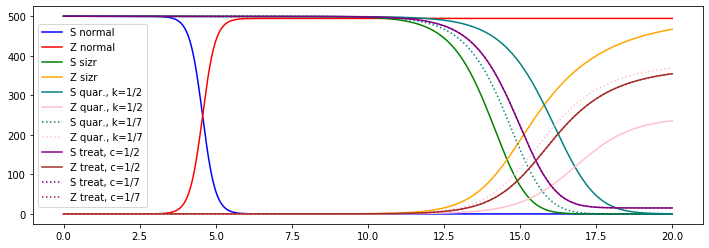

In [3]:
### ANSWER ###

fig = plt.figure(figsize=(12,4))

# The parameters of the model are collected and defined here.
P = 0       # birth rate
d = 0.0001  # natural death percent (per day)
B = 0.0095  # transmission percent  (per day)
G = 0.0001  # resurrect percent (per day)
A = 0.0001   # destroy percent  (per day)
rho = 0.5

def SIZRQ(y, t, P, d, B, G, A, rho, k):
        Si = y[0]
        Ii = y[1]
        Zi = y[2]
        Ri = y[3]
        Qi = y[4]
        # the model equations (see Munz et al. 2009)
        f0 = P - B*Si*Zi - d*Si
        f1 = B*Si*Zi - rho*Ii - d*Ii - k*Ii
        f2 = rho*Ii + G*Ri - A*Si*Zi
        f3 = d*Si + d*Ii + A*Si*Zi - G*Ri
        f4 = k*Ii
        return [f0, f1, f2, f3, f4]
    
def SIZRT(y, t, P, b, B, G, A, rho, c):
        Si = y[0]
        Ii = y[1]
        Zi = y[2]
        Ri = y[3]
        # the model equations (see Munz et al. 2009)
        f0 = P - B*Si*Zi - d*Si + c*Zi
        f1 = B*Si*Zi - rho*Ii - d*Ii
        f2 = rho*Ii + G*Ri - A*Si*Zi - c*Zi
        f3 = d*Si + d*Ii + A*Si*Zi - G*Ri
        return [f0, f1, f2, f3]
    
# initial conditions
S0 = 500.               # initial population
I0 = 0
Z0 = 0                  # initial zombie population
R0 = 0                  # initial death population
Q0 = 0
y0 = [S0, I0, Z0, R0, Q0]       # initial condition vector
t  = np.linspace(0, 20., 1000)   # time grid

y_normal = [S0, Z0, R0]
soln = odeint(f, y_normal, t, args=(P, d, B, G, A))
S = soln[:, 0]
Z = soln[:, 1]
R = soln[:, 2]

plt.plot(t,S,label="S normal",color="blue")
plt.plot(t,Z,label="Z normal",color="red")

# solve the DEs
soln = odeint(SIZR, y0[:4], t, args=(P, d, B, G, A, rho))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]

plt.plot(t,S,label="S sizr", color="green")
plt.plot(t,Z,label="Z sizr", color="orange")

k = 1.0/2.0
# solve the DEs
soln = odeint(SIZRQ, y0, t, args=(P, d, B, G, A, rho, k))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]
Q = soln[:, 4]

plt.plot(t,S,label="S quar., k=1/2",color="teal")
plt.plot(t,Z,label="Z quar., k=1/2",color="pink")

k = 1.0/7.0
# solve the DEs
soln = odeint(SIZRQ, y0, t, args=(P, d, B, G, A, rho, k))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]
Q = soln[:, 4]

plt.plot(t,S,label="S quar., k=1/7",ls=":",color="teal")
plt.plot(t,Z,label="Z quar., k=1/7",ls=":",color="pink")

c = 1.0/2.0
# solve the DEs
soln = odeint(SIZRT, y0[:4], t, args=(P, d, B, G, A, rho, c))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]

plt.plot(t,S,label="S treat, c=1/2",color="purple")
plt.plot(t,Z,label="Z treat, c=1/2",color="brown")

c = 1.0/7.0
# solve the DEs
soln = odeint(SIZRT, y0[:4], t, args=(P, d, B, G, A, rho, c))
S = soln[:, 0]
I = soln[:, 1]
Z = soln[:, 2]
R = soln[:, 3]

plt.plot(t,S,label="S treat, c=1/7",ls=":",color="purple")
plt.plot(t,Z,label="Z treat, c=1/7",ls=":",color="brown")

plt.legend()

**What do you conclude?** Based on your results, what is your recommendation to the CDC? What aspects of the model do you feel need to be refined?

---
## Assignment Wrap-up

Please fill out the form that appears when you run the code below.  **You must completely fill this out in order to receive credit for the assignment!**

In [4]:
from IPython.display import HTML

HTML("""
<iframe 
	src="https://cmse.msu.edu/cmse801-pc-survey" 
	width="800px" 
	height="600px" 
	frameborder="0" 
	marginheight="0" 
	marginwidth="0">
	Loading...
</iframe>
""")

### Congratulations, you're done!

Submit this assignment by uploading it to the course D2L web page.  Go to the "Pre-class assignments" folder, find the submission link for Day 10, and upload it there.

See you in class!

&#169; Copyright 2018,  Michigan State University Board of Trustees